In [1]:
"""
# 10 — Transfer Learning: Introducción

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" CIFAR-10 (imágenes sintéticas de 10 clases)
---
## ¿Qué vamos a aprender en este notebook?
1. Qué es transfer learning y por qué es tan poderoso
2. Qué modelos pre-entrenados están disponibles en Keras
3. Cómo cargar un modelo pre-entrenado en ImageNet
4. Qué es el congelamiento de capas y por qué es necesario
5. Entrenar un clasificador sobre features extraídas con MobileNetV2
---
Transfer learning es probablemente la técnica más importante del deep learning aplicado — permite obtener resultados de nivel
profesional con muy pocos datos y sin necesidad de GPUs costosas.
## 1. ¿Qué es transfer learning?

Transfer learning es la técnica de "reutilizar un modelo entrenado en un problema grande" para resolver un problema más pequeño.
Problema grande (ImageNet):          Nuestro problema:
1.2 millones de imágenes       →     Pocas imágenes
1000 clases                    →     10 clases
Semanas de entrenamiento       →     Minutos de entrenamiento
GPUs costosas                  →     CPU o GPU básica
↓
Modelo pre-entrenado
(ya sabe detectar bordes,
texturas, formas, objetos)
↓
Reutilizar esas features
para nuestro problema

### ¿Por qué funciona?

Las capas tempranas de una CNN entrenada en ImageNet aprenden características "universales" — bordes, texturas, formas — que
son útiles para casi cualquier problema de visión por computadora.
| Capas | Qué aprendieron | ¿Reutilizable? |
|---|---|---|
| "Tempranas" | Bordes, colores, texturas | ✅ Siempre |
| "Medias" | Formas, patrones complejos | ✅ Casi siempre |
| "Profundas" | Conceptos específicos de ImageNet | ⚠️ Depende del problema |
## 2. Estrategias de transfer learning
Hay dos estrategias principales que vamos a explorar en este módulo en detalle:
### Estrategia A — Feature Extraction (este notebook)
Congelar todo el modelo pre-entrenado y entrenar solo un clasificador nuevo sobre las features que extrae.
MobileNetV2 (congelado) → features → Dense(128) → Dense(10)
↑                                    ↑
no aprende                          sí aprende

### Estrategia B — Fine Tuning (notebook 12)
Descongelar algunas capas del modelo pre-entrenado y re-entrenarlas con un learning rate muy pequeño.
MobileNetV2 (últimas capas descongeladas) → Dense(128) → Dense(10)
↑                                           ↑
aprende lentamente                          aprende normalmente

### ¿Cuándo usar cada una?

| Situación | Estrategia recomendada |
|---|---|
| Muy pocos datos (<1000 imágenes) | Feature Extraction |
| Dataset similar a ImageNet | Fine Tuning |
| Dataset muy distinto a ImageNet | Feature Extraction + Fine Tuning |
| Poco tiempo o recursos | Feature Extraction |
"""


'\n# 10 — Transfer Learning: Introducción\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" CIFAR-10 (imágenes sintéticas de 10 clases)\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué es transfer learning y por qué es tan poderoso\n2. Qué modelos pre-entrenados están disponibles en Keras\n3. Cómo cargar un modelo pre-entrenado en ImageNet\n4. Qué es el congelamiento de capas y por qué es necesario\n5. Entrenar un clasificador sobre features extraídas con MobileNetV2\n---\nTransfer learning es probablemente la técnica más importante del deep learning aplicado — permite obtener resultados de nivel\nprofesional con muy pocos datos y sin necesidad de GPUs costosas.\n## 1. ¿Qué es transfer learning?\n\nTransfer learning es la técnica de "reutilizar un modelo entrenado en un problema grande" para resolver un problema más pequeño.\nProblema grande (ImageNet):          Nuestro problema:\n1.2 millones de imágenes       →     Pocas imáge

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [3]:
"""
## 3. Dataset CIFAR-10

Hasta ahora trabajamos con MNIST — imágenes simples en escala de grises.
Para transfer learning vamos a usar "CIFAR-10" — un dataset más desafiante y representativo de problemas reales.

| Característica | MNIST | CIFAR-10 |
|---|---|---|
| "Imágenes" | 70,000 | 60,000 |
| "Tamaño" | 28×28 px | 32×32 px |
| "Canales" | 1 (grises) | 3 (RGB) |
| "Clases" | 10 dígitos | 10 objetos |
| "Dificultad" | Baja | Media |

### Las 10 clases de CIFAR-10
avión, automóvil, pájaro, gato, ciervo,
perro, rana, caballo, barco, camión

CIFAR-10 es mucho más desafiante que MNIST porque las imágenes tienen variaciones de iluminación, fondo, posición y escala —
exactamente el tipo de variabilidad que encontramos en problemas reales.
"""

'\n## 3. Dataset CIFAR-10\n\nHasta ahora trabajamos con MNIST — imágenes simples en escala de grises.\nPara transfer learning vamos a usar "CIFAR-10" — un dataset más desafiante y representativo de problemas reales.\n\n| Característica | MNIST | CIFAR-10 |\n|---|---|---|\n| "Imágenes" | 70,000 | 60,000 |\n| "Tamaño" | 28×28 px | 32×32 px |\n| "Canales" | 1 (grises) | 3 (RGB) |\n| "Clases" | 10 dígitos | 10 objetos |\n| "Dificultad" | Baja | Media |\n\n### Las 10 clases de CIFAR-10\navión, automóvil, pájaro, gato, ciervo,\nperro, rana, caballo, barco, camión\n\nCIFAR-10 es mucho más desafiante que MNIST porque las imágenes tienen variaciones de iluminación, fondo, posición y escala —\nexactamente el tipo de variabilidad que encontramos en problemas reales.\n'

In [4]:
# Cargar CIFAR-10
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Nombres de las clases
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Aplanar etiquetas de (N, 1) a (N,)
y_train = y_train.flatten()
y_test  = y_test.flatten()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# Separar validación
X_val   = X_train_raw[45000:]
X_train = X_train_raw[:45000]
y_val   = y_train[45000:]
y_train = y_train[:45000]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Clases: {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 984s 6us/step


C:\Users\Peter\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (45000, 32, 32, 3)
Val:   (5000, 32, 32, 3)
Test:  (10000, 32, 32, 3)
Clases: ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']


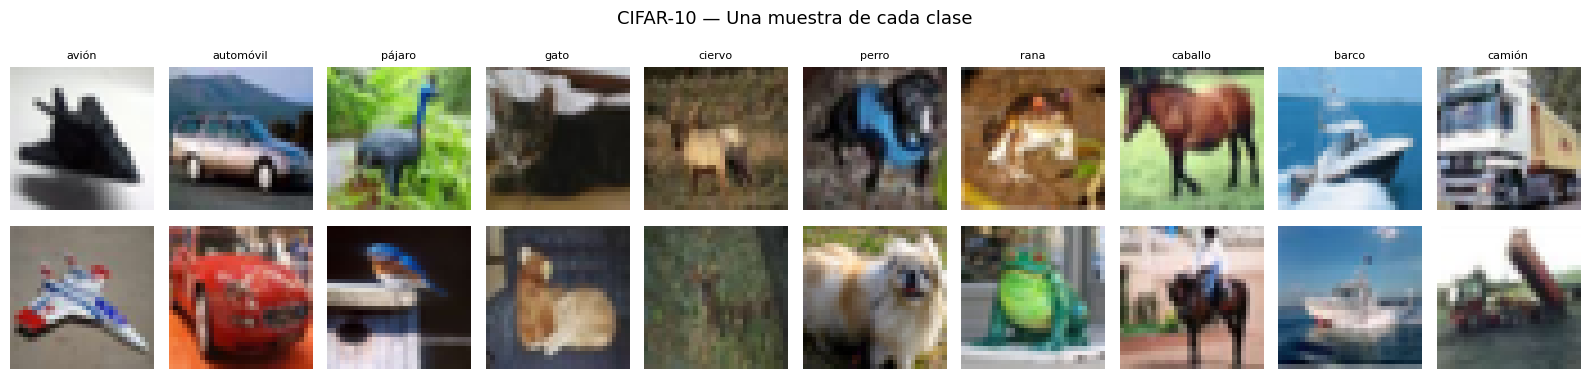

In [5]:
# Visualizar muestras de cada clase
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('CIFAR-10 — Una muestra de cada clase', fontsize=13)

for cls in range(10):
    idx = np.where(y_train == cls)[0][0]

    # Fila 1: primer ejemplo
    axes[0, cls].imshow(X_train[idx])
    axes[0, cls].set_title(class_names[cls], fontsize=8)
    axes[0, cls].axis('off')

    # Fila 2: segundo ejemplo
    idx2 = np.where(y_train == cls)[0][1]
    axes[1, cls].imshow(X_train[idx2])
    axes[1, cls].axis('off')

plt.tight_layout()
plt.savefig('../figures/10_cifar10_muestras.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
"""
## 4. MobileNetV2 — El modelo pre-entrenado

Vamos a usar "MobileNetV2" como modelo base. Es una arquitectura diseñada para ser eficiente y liviana, ideal para aprender
transfer learning porque:

| Característica | Detalle |
|---|---|
| "Parámetros" | ~3.4 millones |
| "Entrenado en" | ImageNet (1.2M imágenes, 1000 clases) |
| "Input esperado" | 96×96 px mínimo, recomendado 224×224 |
| "Velocidad" | Muy rápido — diseñado para dispositivos móviles |

### ¿Por qué no VGG16 o ResNet50?
- VGG16 tiene 138M parámetros — muy pesado para este notebook
- ResNet50 tiene 25M parámetros — más manejable pero aún grande
- MobileNetV2 con 3.4M parámetros es perfecto para aprender
  el concepto sin tiempos de espera largos
En proyectos reales donde tenés más recursos, ResNet50 o EfficientNet son mejores puntos de partida que MobileNetV2.
"""

'\n## 4. MobileNetV2 — El modelo pre-entrenado\n\nVamos a usar "MobileNetV2" como modelo base. Es una arquitectura diseñada para ser eficiente y liviana, ideal para aprender\ntransfer learning porque:\n\n| Característica | Detalle |\n|---|---|\n| "Parámetros" | ~3.4 millones |\n| "Entrenado en" | ImageNet (1.2M imágenes, 1000 clases) |\n| "Input esperado" | 96×96 px mínimo, recomendado 224×224 |\n| "Velocidad" | Muy rápido — diseñado para dispositivos móviles |\n\n### ¿Por qué no VGG16 o ResNet50?\n- VGG16 tiene 138M parámetros — muy pesado para este notebook\n- ResNet50 tiene 25M parámetros — más manejable pero aún grande\n- MobileNetV2 con 3.4M parámetros es perfecto para aprender\n  el concepto sin tiempos de espera largos\nEn proyectos reales donde tenés más recursos, ResNet50 o EfficientNet son mejores puntos de partida que MobileNetV2.\n'

In [7]:
# MobileNetV2 espera imágenes de al menos 96×96
# CIFAR-10 es 32×32 — necesitamos redimensionar
IMG_SIZE = 96

# Redimensionar dataset
X_train_resized = tf.image.resize(X_train, (IMG_SIZE, IMG_SIZE)).numpy()
X_val_resized   = tf.image.resize(X_val,   (IMG_SIZE, IMG_SIZE)).numpy()
X_test_resized  = tf.image.resize(X_test,  (IMG_SIZE, IMG_SIZE)).numpy()

print(f"Train redimensionado: {X_train_resized.shape}")

# Cargar MobileNetV2 sin la cabeza de clasificación
# include_top=False → excluye las capas Dense finales
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,      # Sin clasificador final
    weights='imagenet'      # Pesos pre-entrenados en ImageNet
)

print(f"\nMobileNetV2 cargado correctamente")
print(f"Parámetros totales: {base_model.count_params():,}")
print(f"Output shape: {base_model.output_shape}")

Train redimensionado: (45000, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

MobileNetV2 cargado correctamente
Parámetros totales: 2,257,984
Output shape: (None, 3, 3, 1280)


In [8]:
# Congelar el modelo base
base_model.trainable = False

print(f"Capas totales en MobileNetV2: {len(base_model.layers)}")
print(f"Capas entrenables: {len([l for l in base_model.layers if l.trainable])}")

# Construir modelo completo
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Preprocesamiento específico de MobileNetV2
# Escala píxeles de [0,1] a [-1, 1] como espera el modelo
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)

# Pasar por MobileNetV2 congelado
x = base_model(x, training=False)  # training=False → BatchNorm en modo inferencia

# Reducir dimensiones espaciales
x = layers.GlobalAveragePooling2D()(x)

# Clasificador nuevo — lo único que vamos a entrenar
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model_fe = Model(inputs=inputs, outputs=outputs, name='MobileNetV2_FeatureExtraction')

print(f"\nParámetros totales:      {model_fe.count_params():,}")
print(f"Parámetros entrenables:  {sum([tf.size(w).numpy() for w in model_fe.trainable_weights]):,}")
print(f"Parámetros congelados:   {sum([tf.size(w).numpy() for w in model_fe.non_trainable_weights]):,}")

Capas totales en MobileNetV2: 154
Capas entrenables: 0

Parámetros totales:      2,423,242
Parámetros entrenables:  165,258
Parámetros congelados:   2,257,984


In [9]:
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando modelo con feature extraction...")
history_fe = model_fe.fit(
    X_train_resized, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_resized, y_val),
    verbose=1
)

val_acc  = max(history_fe.history['val_accuracy'])
test_loss, test_acc = model_fe.evaluate(X_test_resized, y_test, verbose=0)
print(f"\nMejor val_accuracy: {val_acc*100:.1f}%")
print(f"Test accuracy:      {test_acc*100:.1f}%")

Entrenando modelo con feature extraction...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 215s 291ms/step - accuracy: 0.7975 - loss: 0.5996 - val_accuracy: 0.8556 - val_loss: 0.4059
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 278ms/step - accuracy: 0.8506 - loss: 0.4300 - val_accuracy: 0.8652 - val_loss: 0.3901
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 278ms/step - accuracy: 0.8710 - loss: 0.3766 - val_accuracy: 0.8686 - val_loss: 0.3892
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 194s 275ms/step - accuracy: 0.8846 - loss: 0.3404 - val_accuracy: 0.8662 - val_loss: 0.3795
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 192s 273ms/step - accuracy: 0.8893 - loss: 0.3124 - val_accuracy: 0.8592 - val_loss: 0.4101
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 195s 277ms/step - accuracy: 0.8970 - loss: 0.2881 - val_accuracy: 0.8718 - val_loss: 0.3792
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 281ms/step - accuracy: 0.9045 - loss: 0.2689 - val_accuracy: 0.8684 - val_loss: 0.3984
Epoch 8/10
704/704 ━━━━━━━━━━━━━

In [10]:
"""
## 6. Visualizar predicciones

Vamos a visualizar las predicciones del modelo sobre el test set
para entender qué clases confunde y cuáles clasifica bien.

En CIFAR-10 es esperable que el modelo confunda clases visualmente similares — gato/perro, automóvil/camión,
avión/barco — porque son categorías que comparten muchas características visuales.
"""

'\n## 6. Visualizar predicciones\n\nVamos a visualizar las predicciones del modelo sobre el test set\npara entender qué clases confunde y cuáles clasifica bien.\n\nEn CIFAR-10 es esperable que el modelo confunda clases visualmente similares — gato/perro, automóvil/camión,\navión/barco — porque son categorías que comparten muchas características visuales.\n'

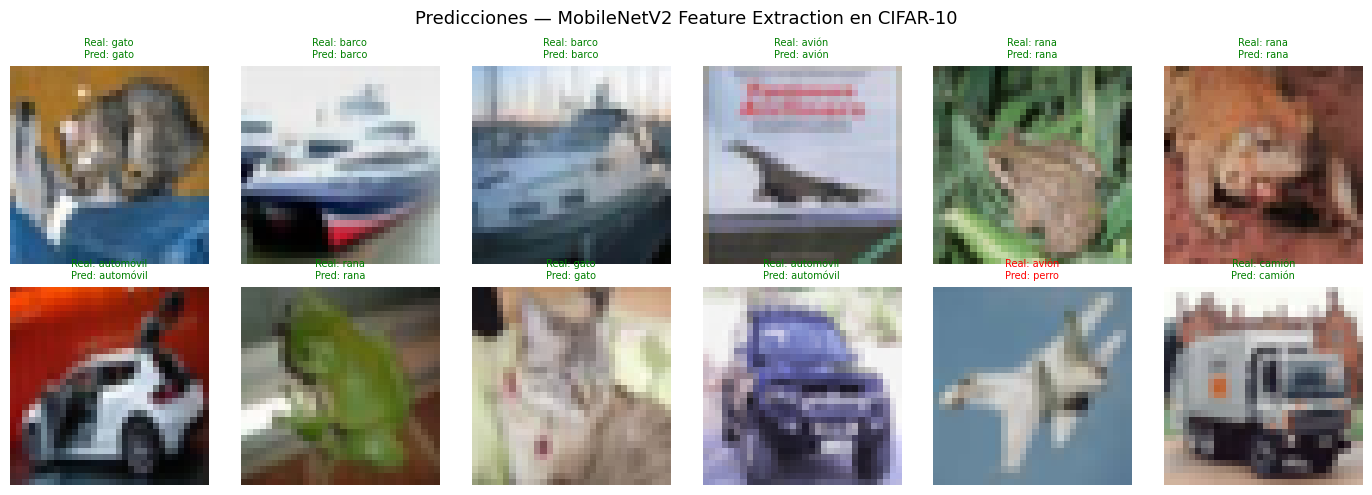

Verde = correcto | Rojo = error


In [11]:
# Predicciones sobre el test set
y_pred_probs = model_fe.predict(X_test_resized, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Visualizar 12 ejemplos del test set
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Predicciones — MobileNetV2 Feature Extraction en CIFAR-10', fontsize=13)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_test[i])
    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f'Real: {true_label}\nPred: {pred_label}',
                 fontsize=7, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/10_predicciones_cifar10.png', dpi=120, bbox_inches='tight')
plt.show()
print("Verde = correcto | Rojo = error")

In [12]:
"""
## 7. Matriz de confusión

Con 10 clases visualmente similares la matriz de confusión nos va a mostrar patrones interesantes:
- ¿Confunde gato con perro?
- ¿Confunde automóvil con camión?
- ¿Qué clase clasifica mejor y cuál peor?
Analizar los errores sistemáticos del modelo es el primer paso para mejorarlo — si sabemos que confunde gato con perro
podemos agregar más ejemplos de esas clases o ajustar el preprocesamiento.
"""

'\n## 7. Matriz de confusión\n\nCon 10 clases visualmente similares la matriz de confusión nos va a mostrar patrones interesantes:\n- ¿Confunde gato con perro?\n- ¿Confunde automóvil con camión?\n- ¿Qué clase clasifica mejor y cuál peor?\nAnalizar los errores sistemáticos del modelo es el primer paso para mejorarlo — si sabemos que confunde gato con perro\npodemos agregar más ejemplos de esas clases o ajustar el preprocesamiento.\n'

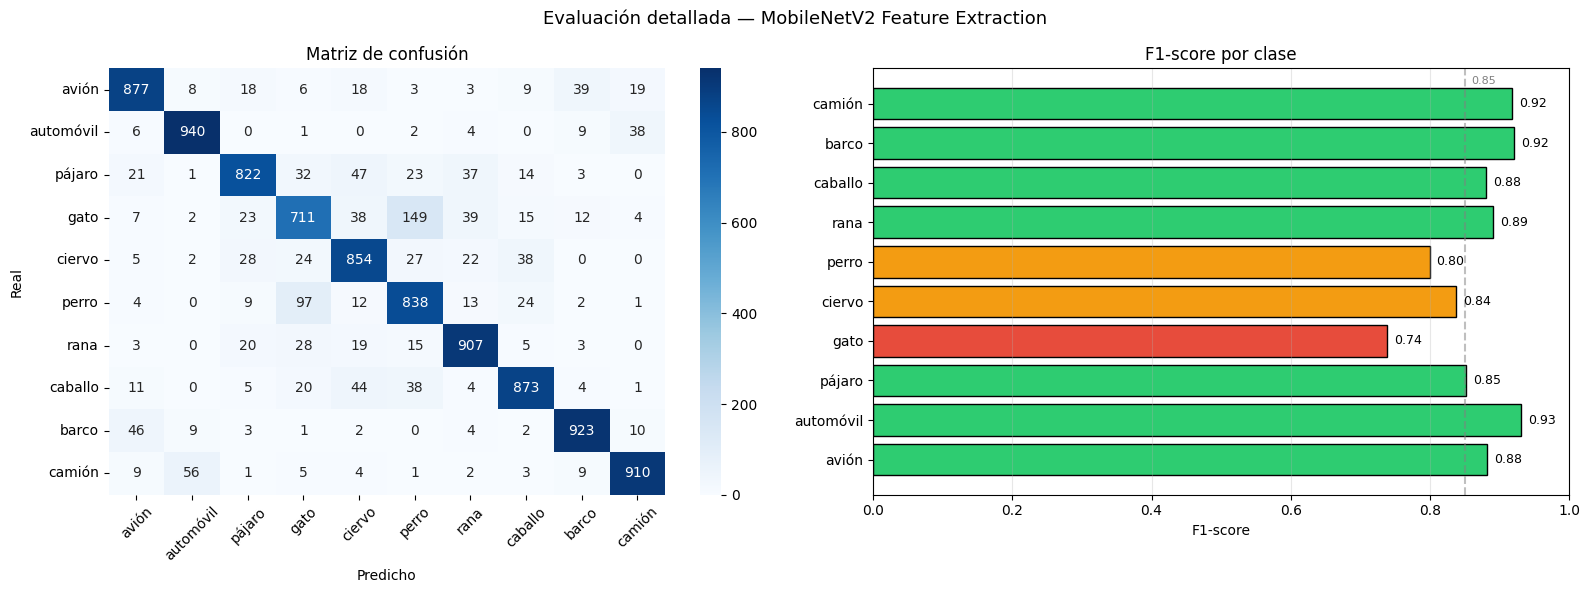

              precision    recall  f1-score   support

       avión       0.89      0.88      0.88      1000
   automóvil       0.92      0.94      0.93      1000
      pájaro       0.88      0.82      0.85      1000
        gato       0.77      0.71      0.74      1000
      ciervo       0.82      0.85      0.84      1000
       perro       0.76      0.84      0.80      1000
        rana       0.88      0.91      0.89      1000
     caballo       0.89      0.87      0.88      1000
       barco       0.92      0.92      0.92      1000
      camión       0.93      0.91      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluación detallada — MobileNetV2 Feature Extraction', fontsize=13)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Matriz de confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# F1-score por clase
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, y_pred, average=None)
colores   = ['#2ecc71' if f >= 0.85 else '#f39c12' if f >= 0.75 else '#e74c3c'
             for f in f1_scores]

axes[1].barh(class_names, f1_scores, color=colores, edgecolor='black')
axes[1].set_xlim(0, 1)
axes[1].set_title('F1-score por clase')
axes[1].set_xlabel('F1-score')
axes[1].axvline(x=0.85, color='gray', linestyle='--', alpha=0.5)
axes[1].text(0.86, 9.5, '0.85', fontsize=8, color='gray')
axes[1].grid(axis='x', alpha=0.3)

for i, f in enumerate(f1_scores):
    axes[1].text(f + 0.01, i, f'{f:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/10_confusion_matrix_cifar10.png', dpi=120, bbox_inches='tight')
plt.show()

# Reporte
print(classification_report(y_test, y_pred, target_names=class_names))